We model the following ODE driven by the El Centro Earthquake:
$$
\ddot u(t) + 2\xi\omega_n\,\dot u(t) + \omega_n^{2}u(t)
        = -9.81\,a(t),
\qquad
u(0)=\dot u(0)=0,
$$
where $a(t)$ is the normalized ground-acceleration record, $\xi$ is the damping ratio, and $\omega_n$ is the natural frequency.


In the experiment, we take:
- $\xi = 0.02$
- $T_n = 5\,\mathrm{s}$
- $\omega_n = 2\pi/T_n$
 

## Imports

In [13]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.elcentro import *
print("Using device:", device, "torch", torch.__version__)

Already up to date.
Using device: cuda torch 2.11.0+cu128


## Problem and Model Parameters

In [ ]:
# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81



window_size = 400
signature_level = 12




## Import Forcing and data

In [15]:
import os
os.chdir("/content/BSK_ODE")    # <- adjust if your clone path is different
print("CWD:", os.getcwd())
print("Here:", os.listdir())    # should show 'Data', 'experiments', etc.
print("Data:", os.listdir("Data"))  # should show 'EQDATA.csv'
F_t = pd.read_csv("Data/EQDATA.csv")        # from repo root
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
t_start = 0
t_end = 31.18
num_partitions = 1560
total_points = len(F_t)
partition_size = total_points // num_partitions
dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)


CWD: /content/BSK_ODE
Here: ['readme.md', 'experiments', 'bsk_ode', 'Paper_runs', 'Data', '.git']
Data: ['econ_f_t_gdp_normalized_time.csv', 'EQDATA.csv']


## Run calibration

In [ ]:
t_ref, U_ref = solve_linear_ivp(
    x_grid = t_vals,
    forcing_torch = F_vals,
    a = t_start, 
    b = t_end,
    ya = 0, 
    ypa = 0,
    k1 = m, 
    k2 = c,
    k3 = k
    )

U_hat, F_hat = solve_signature_kernel(
    x=t_vals,        # time grid
    f=F_vals,        # raw forcing (a_g * acceleration)
    k1=m,            # mass
    k2=c,            # damping
    k3=k,            # stiffness
    ua=0.0,          # u(0)
    upa=0.0,         # u'(0)
    depth=signature_level,
    normalize=True,
)

non-branched integrated-target loss: 1.353e-03


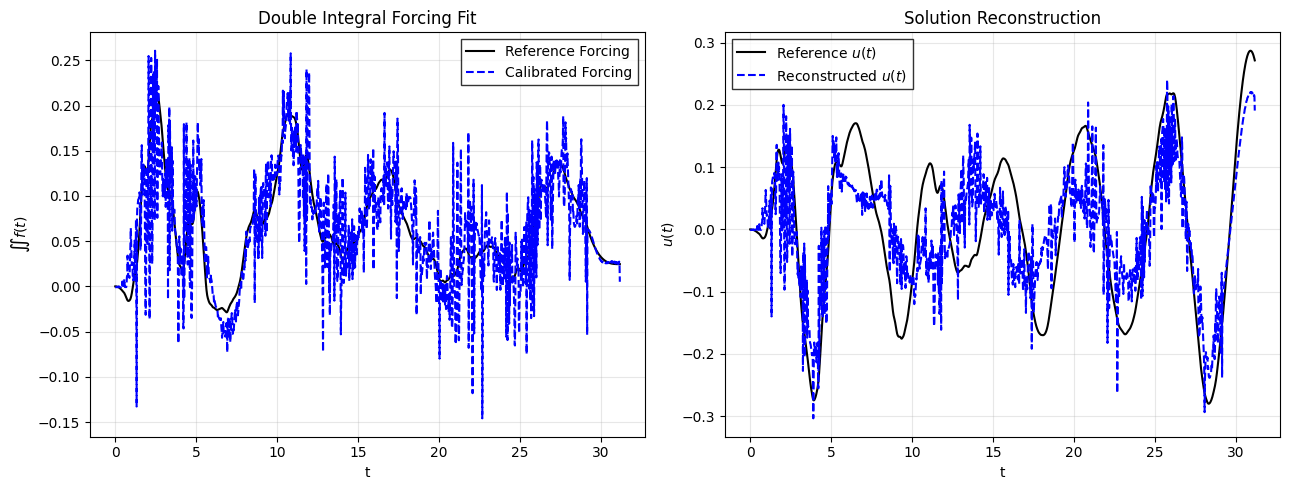

In [ ]:
plot_calibration(t_vals, F_star, F_hat, U_ref, U_hat)
print_errors(F_hat,F_star,U_hat,U_ref)

# CONVERT: george convert in style above

# Rolling Retrain

In [ ]:
paths_b, paths_nb = build_paths(F_t, num_partitions=num_partitions)

state_b  = build_state(paths_b,  n0, signature_level, m, c, k, dt, N,
                       F_star, t_vals, U_ref)
state_nb = build_state(paths_nb, n0, signature_level, m, c, k, dt, N,
                       F_star, t_vals, U_ref)
print("TRAIN DONE.")

res_b  = rolling_online_predict(state_b,  retrain_every=5)
res_nb = rolling_online_predict(state_nb, retrain_every=5)

TRAIN DONE.
Running branched (t-lift)...
[Retrain] at index 205
[Retrain] at index 210
[Retrain] at index 215
[Retrain] at index 220
[Retrain] at index 225
[Retrain] at index 230
[Retrain] at index 235
[Retrain] at index 240
[Retrain] at index 245
[Retrain] at index 250
[Retrain] at index 255
[Retrain] at index 260
[Retrain] at index 265
[Retrain] at index 270
[Retrain] at index 275
[Retrain] at index 280
[Retrain] at index 285
[Retrain] at index 290
[Retrain] at index 295
[Retrain] at index 300
[Retrain] at index 305
[Retrain] at index 310
[Retrain] at index 315
[Retrain] at index 320
[Retrain] at index 325
[Retrain] at index 330
[Retrain] at index 335
[Retrain] at index 340
[Retrain] at index 345
[Retrain] at index 350
[Retrain] at index 355
[Retrain] at index 360
[Retrain] at index 365
[Retrain] at index 370
[Retrain] at index 375
[Retrain] at index 380
[Retrain] at index 385
[Retrain] at index 390
[Retrain] at index 395
[Retrain] at index 400
[Retrain] at index 405
[Retrain] at ind

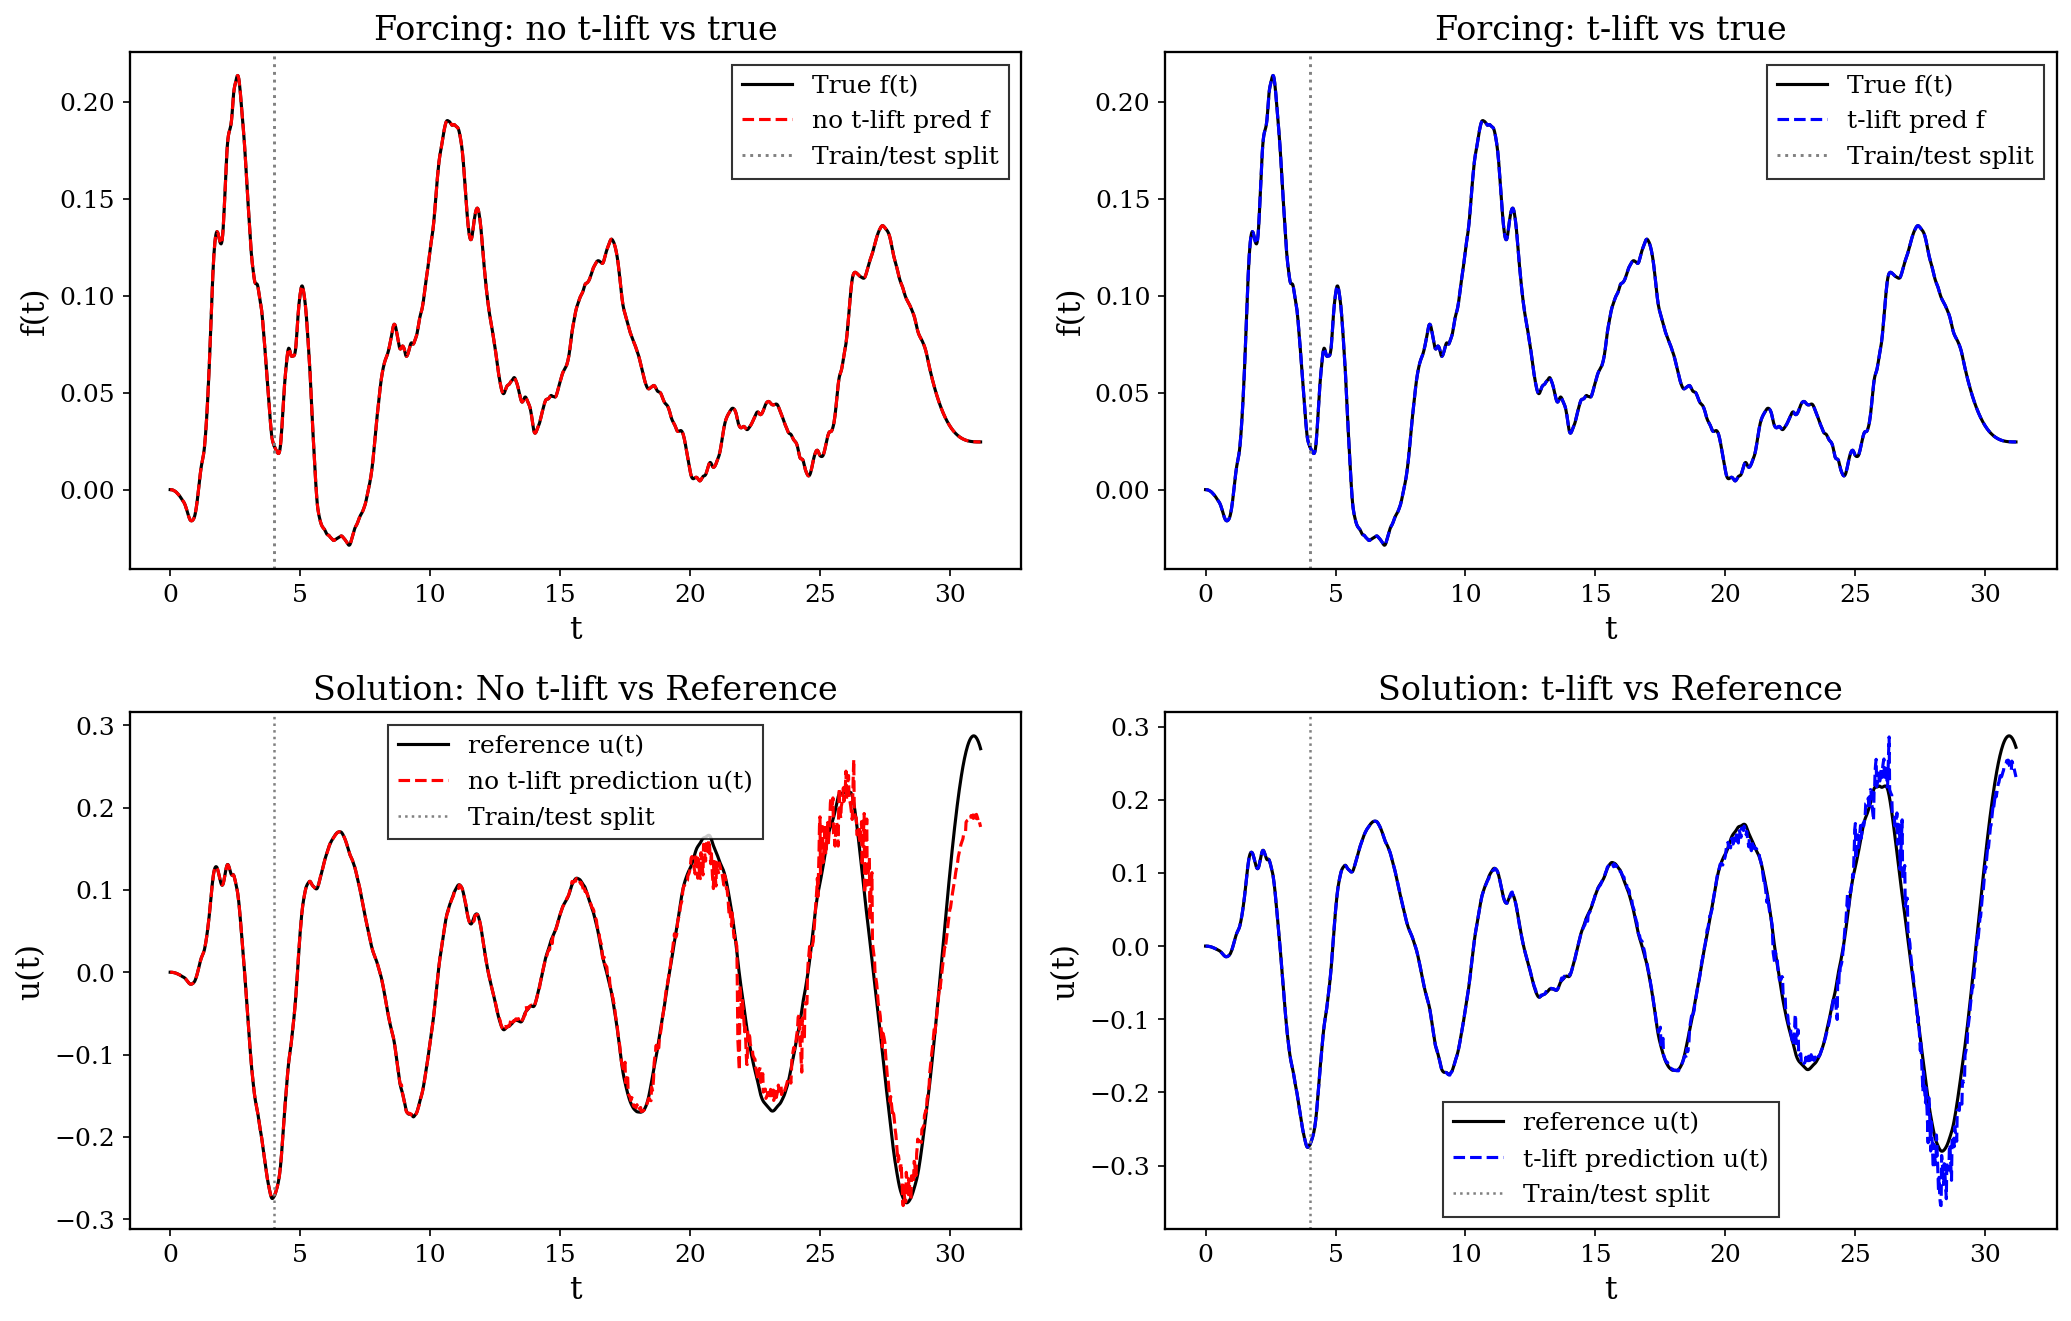

In [ ]:
plot_branched_vs_nonbranched(
    t_vals,
    n0,
    F_star,
    F_pred_train_nb,
    F_pred_train_b,
    u_true_interp,
    u_pred_train_nb,
    u_pred_train_b,
    res_nb,
    res_b,
)

In [ ]:
res_b  = rolling_online_predict(state_branched,  retrain_every=5)
res_nb = rolling_online_predict(state_nonbranched, retrain_every=5)

summarize_branched_vs_nonbranched_errors(
    t_vals,
    n0,
    F_star,
    u_true_interp,
    F_pred_train_nb,
    F_pred_train_b,
    u_pred_train_nb,
    u_pred_train_b,
    res_nb,
    res_b,
)


                             Non-Branched  t-lift Branched  % Improvement
------------------------------------------------------------------------
Training forcing               9.1953e-13       2.1603e-13         76.51%
Training solution              9.5306e-07       9.5300e-07          0.01%
Testing forcing                3.2033e-22       2.3255e-25         99.93%
Testing solution               3.3817e-02       1.2857e-02         61.98%
